In [3]:
import os
import random
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from IPython.display import Image
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.applications import imagenet_utils
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model

In [2]:
# Source - https://stackoverflow.com/a
# Posted by Reghunaath A A, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-07, License - CC BY-SA 4.0

!pip install --upgrade protobuf


In [4]:
FAST_RUN = False
IMAGE_WIDTH=224
IMAGE_HEIGHT=224
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT)
IMAGE_CHANNELS=3

In [5]:
filenames = os.listdir(r"/kaggle/input/pcb-dataset/dataset/dataset/train/train5")
labels = []

for filename in filenames:
    label = filename.split(' ')[0]
    if label == 'good':
        labels.append(0)
    else:
        labels.append(1)

df = pd.DataFrame({
    'filename': filenames,
    'label': labels
})

In [6]:
base_model=MobileNet(weights='imagenet',include_top=False)  #imports the mobilenet model and discards the last 1000 neuron layer.

x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dense(1024,activation='relu')(x)                          #we add dense layers so that the model can learn more complex functions and classify for better results.
x=Dense(1024,activation='relu')(x)                          #dense layer 2
x=Dense(512,activation='relu')(x)                           #dense layer 3
preds=Dense(2,activation='softmax')(x)                      #final layer with softmax activation

/tmp/ipykernel_48/4263714052.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model=MobileNet(weights='imagenet',include_top=False)  #imports the mobilenet model and discards the last 1000 neuron layer.
2025-11-08 18:55:01.731284: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
model=Model(inputs=base_model.input,outputs=preds)

In [8]:
model.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy']) 

In [9]:
for layer in model.layers[:20]:
    layer.trainable=False
for layer in model.layers[20:]:
    layer.trainable=True

In [10]:
earlystop = EarlyStopping(patience=10)

In [11]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', 
                                            patience=2, 
                                            verbose=1, 
                                            factor=0.5, 
                                            min_lr=0.00001)

In [12]:
callbacks = [earlystop, learning_rate_reduction]

In [13]:
df["label"] = df["label"].replace({0: 'Good', 1: 'Bad'}) 

In [14]:
train_df, validate_df = train_test_split(df, test_size=0.20, random_state=42)
train_df = train_df.reset_index(drop=True)
validate_df = validate_df.reset_index(drop=True)

<Axes: xlabel='label'>

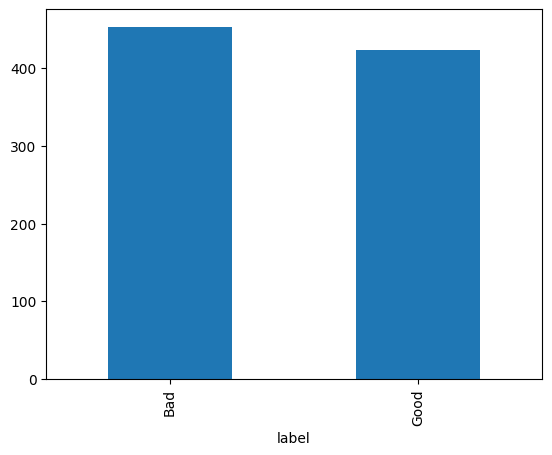

In [18]:
train_df['label'].value_counts().plot.bar()

In [19]:
total_train = train_df.shape[0]
total_validate = validate_df.shape[0]
batch_size=15

In [20]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    rescale=1./255,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_generator = train_datagen.flow_from_dataframe(
    train_df, 
    r"/kaggle/input/pcb-dataset/dataset/dataset/train/train5", 
    x_col='filename',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    batch_size=batch_size
)

Found 876 validated image filenames belonging to 2 classes.


In [21]:
validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow_from_dataframe(
    validate_df, 
    r"/kaggle/input/pcb-dataset/dataset/dataset/train/train5", 
    x_col='filename',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    batch_size=batch_size
)    

Found 219 validated image filenames belonging to 2 classes.


In [22]:
epochs=3 if FAST_RUN else 15
history = model.fit(
    train_generator, 
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=total_validate//batch_size,
    steps_per_epoch=total_train//batch_size,
    callbacks=callbacks
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.6469 - loss: 0.8597 - val_accuracy: 0.7048 - val_loss: 1.6293 - learning_rate: 0.0010
Epoch 2/15
 1/58 ━━━━━━━━━━━━━━━━━━━━ 53s 933ms/step - accuracy: 0.9333 - loss: 0.3740

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.9333 - loss: 0.3740 - val_accuracy: 0.7190 - val_loss: 1.4701 - learning_rate: 0.0010
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9166 - loss: 0.2524 - val_accuracy: 0.9190 - val_loss: 0.2713 - learning_rate: 0.0010
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 1.0000 - loss: 0.1058 - val_accuracy: 0.9286 - val_loss: 0.2694 - learning_rate: 0.0010
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9329 - loss: 0.2257 - val_accuracy: 0.8381 - val_loss: 1.0393 - learning_rate: 0.0010
Epoch 6/15
 1/58 ━━━━━━━━━━━━━━━━━━━━ 51s 908ms/step - accuracy: 0.9333 - loss: 0.2808
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.9333 - loss: 0.2808 - val_accuracy: 0.8381 - val_loss: 0.7921 - learning_rate: 0.0010
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9189 - loss: 0.2531 - val_accuracy: 0.8667

In [23]:
model.save_weights("model.weights.h5")

In [24]:
model.save('/kaggle/working/model.h5')

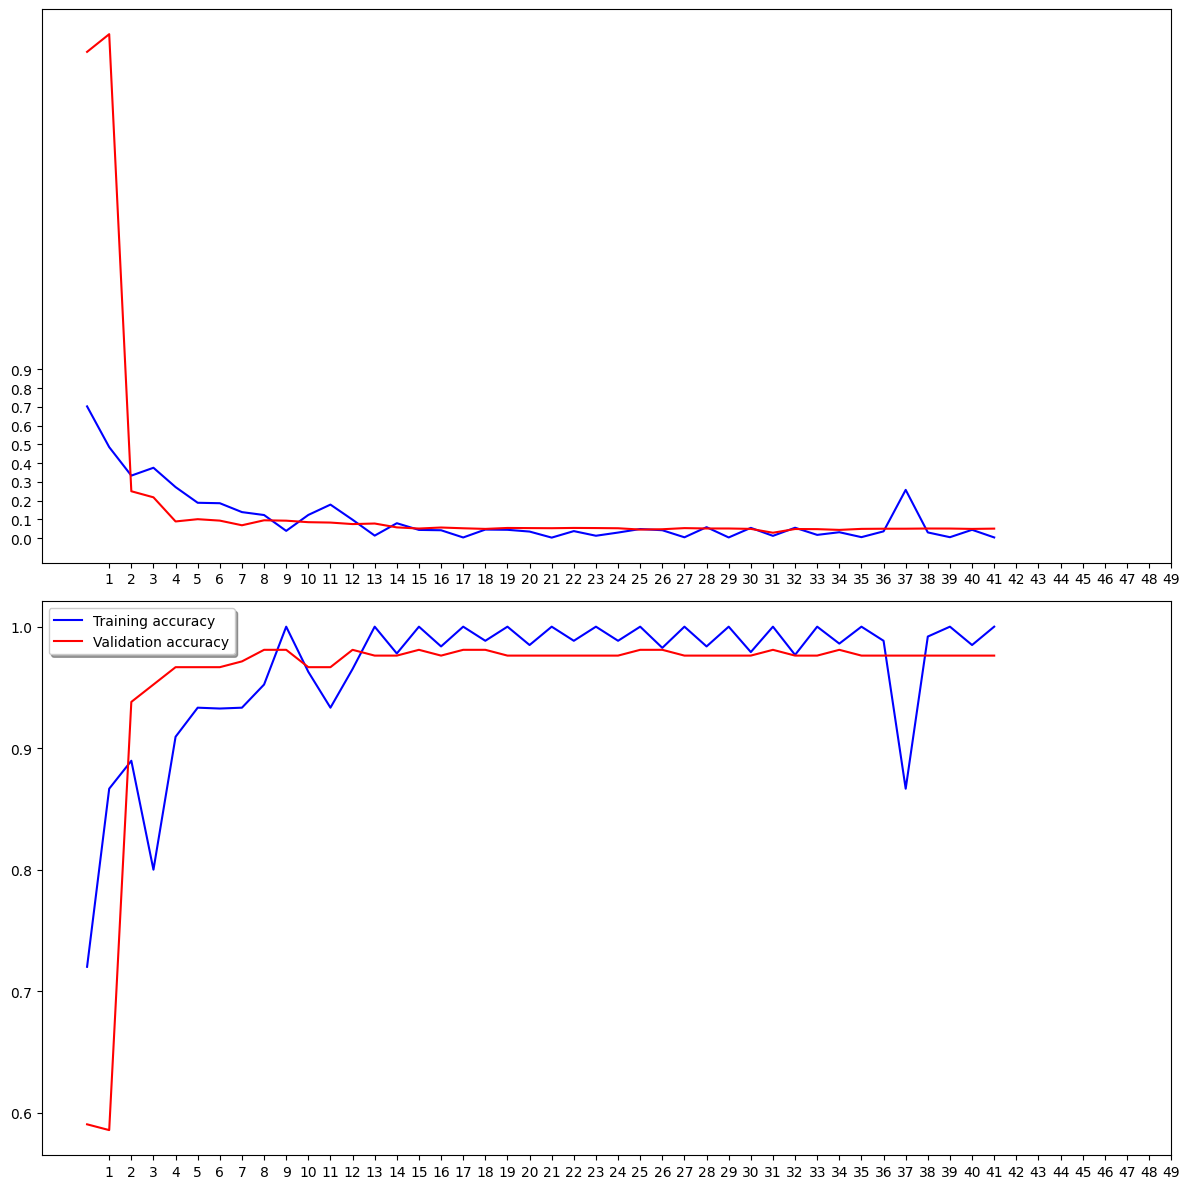

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
ax1.plot(history.history['loss'], color='b', label="Training loss")
ax1.plot(history.history['val_loss'], color='r', label="validation loss")
ax1.set_xticks(np.arange(1, epochs, 1))
ax1.set_yticks(np.arange(0, 1, 0.1))

ax2.plot(history.history['accuracy'], color='b', label="Training accuracy")
ax2.plot(history.history['val_accuracy'], color='r',label="Validation accuracy")
ax2.set_xticks(np.arange(1, epochs, 1))

legend = plt.legend(loc='best', shadow=True)
plt.tight_layout()
plt.show()

In [35]:
model = load_model(r'/kaggle/working/model.h5')

In [36]:
import cv2
img = cv2.imread(r'/kaggle/input/pcb-dataset/dataset/dataset/test/test5/bad (439)k.jpeg')
img = img[...,::-1]                                                                 #give right image or else it will show error
model.predict(img[None,...], batch_size=None, verbose=2, steps=1)

1/1 - 0s - 448ms/step


array([[0.49291068, 0.5070894 ]], dtype=float32)

In [37]:
test_filenames = os.listdir(r"/kaggle/input/pcb-dataset/dataset/dataset/test/test5")
test_df = pd.DataFrame({
    'filename': test_filenames
})
nb_samples = test_df.shape[0]

In [38]:
test_gen = ImageDataGenerator(rescale=1./255)
test_generator = test_gen.flow_from_dataframe(
    test_df, 
    r"/kaggle/input/pcb-dataset/dataset/dataset/test/test5", 
    x_col='filename',
    y_col=None,
    class_mode=None,
    target_size=IMAGE_SIZE,
    batch_size=batch_size,
    shuffle=False
)

Found 100 validated image filenames.


In [40]:
predict = model.predict(test_generator, steps=int(np.ceil(nb_samples / batch_size)))


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step


In [41]:
test_df['label'] = np.argmax(predict, axis=-1)

In [42]:
label_map = dict((v,k) for k,v in train_generator.class_indices.items())
test_df['label'] = test_df['label'].replace(label_map)

<Axes: xlabel='label'>

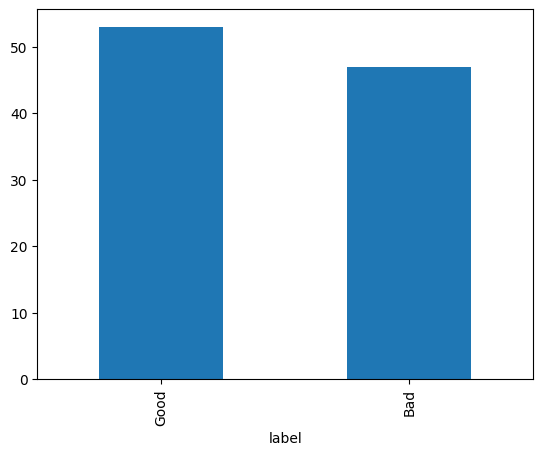

In [43]:
test_df['label'].value_counts().plot.bar()

In [ ]:
#/kaggle/input/pcb-dataset/dataset/dataset/test/test5/good (447)k.jpeg

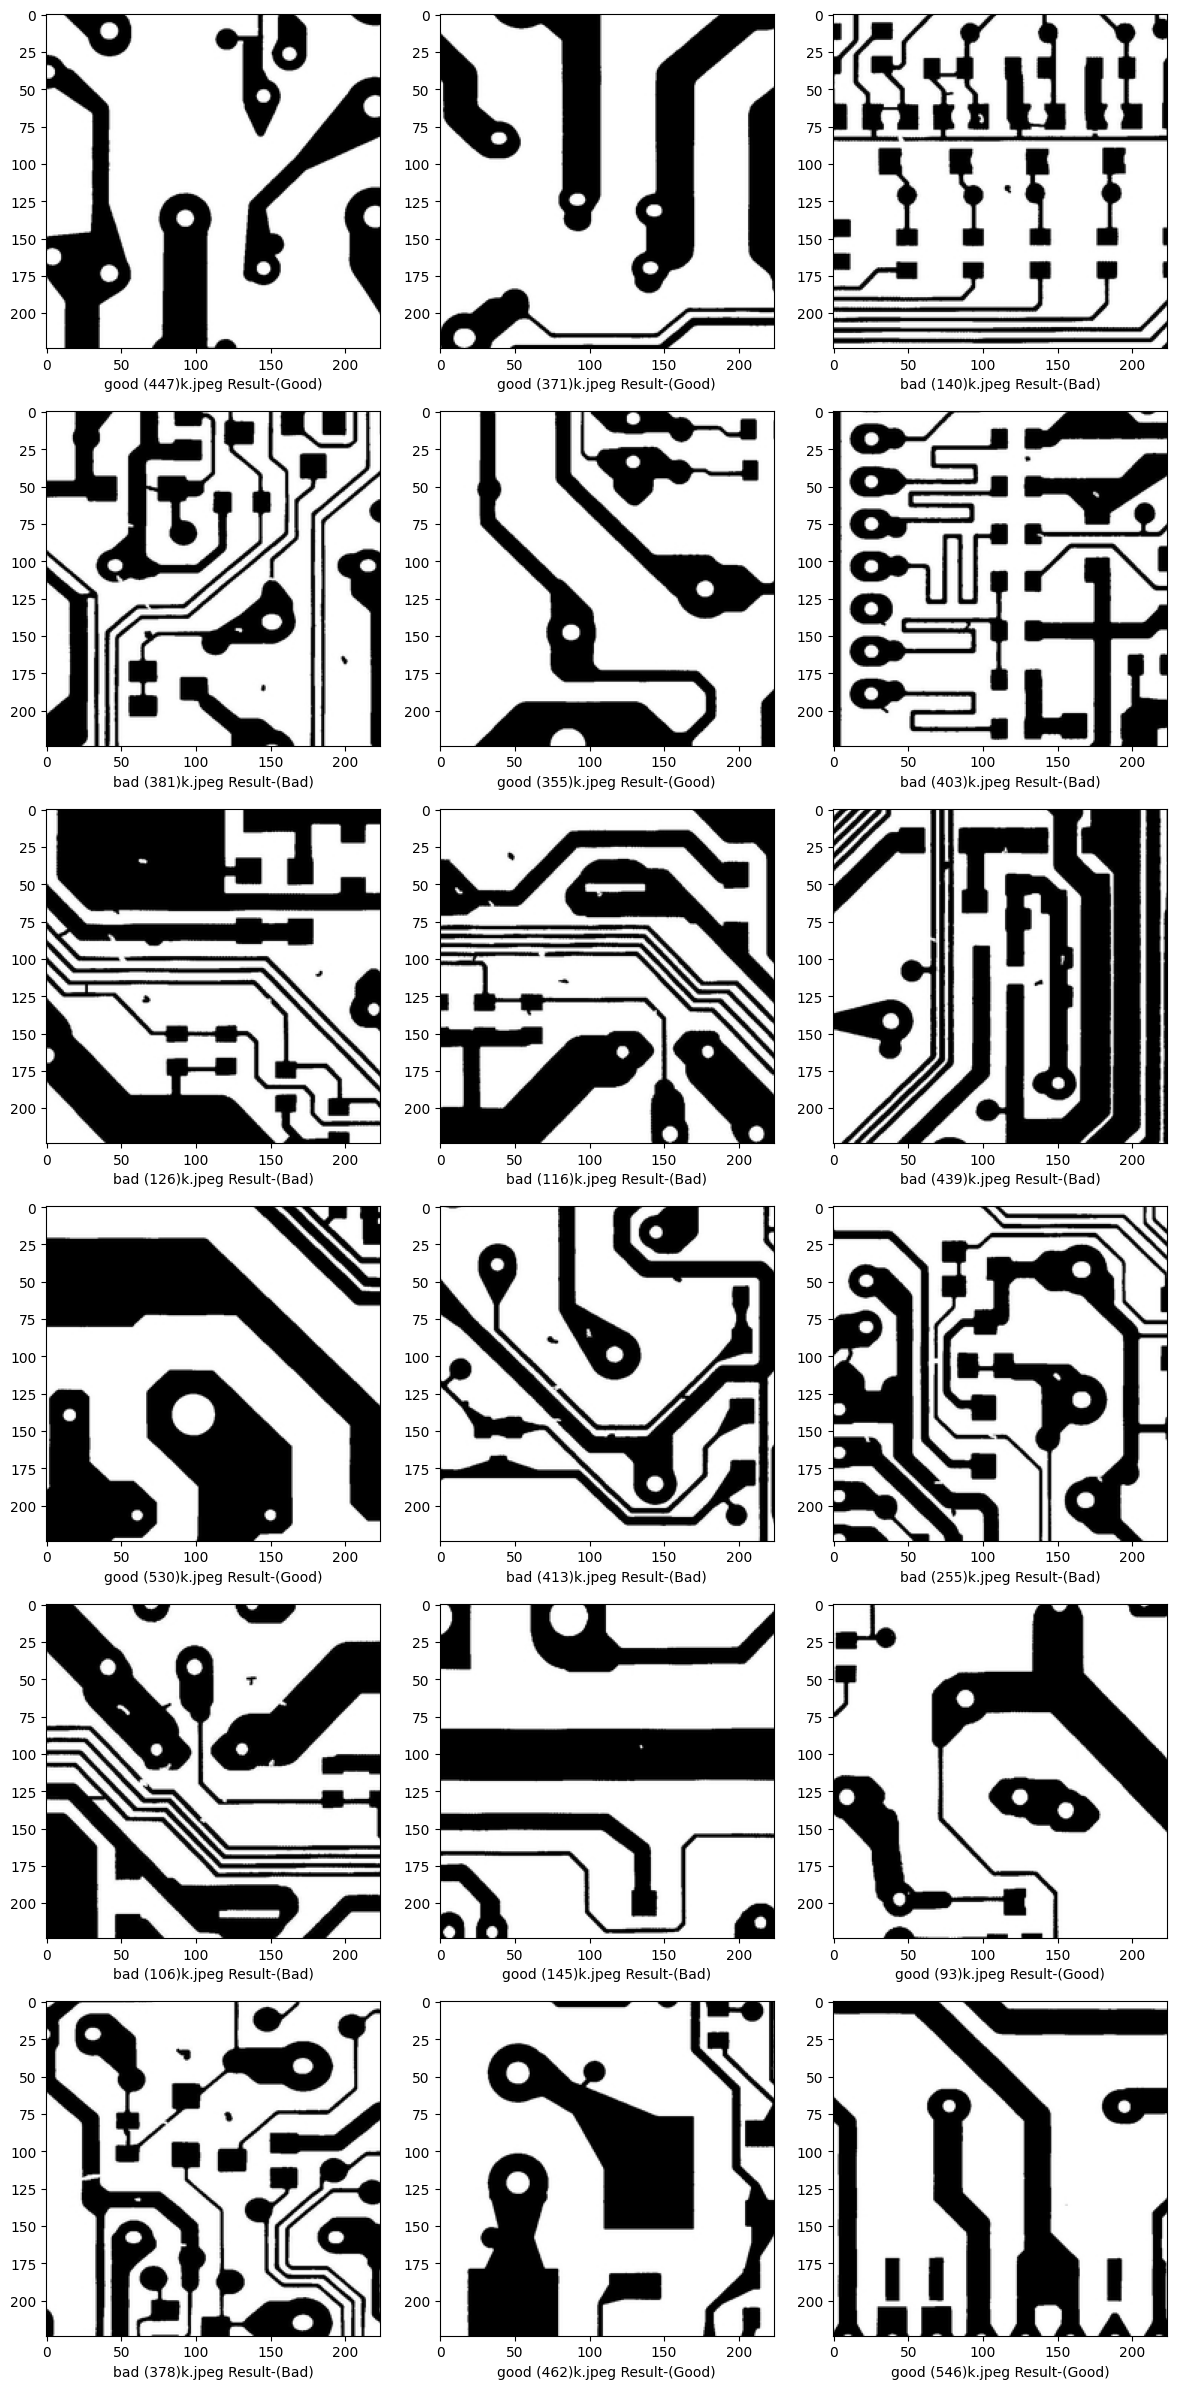

In [45]:
sample_test = test_df.head(18)
sample_test.head()
plt.figure(figsize=(12, 24))
for index, row in sample_test.iterrows():
    filename = row['filename']
    category = row['label']
    img = load_img(r"/kaggle/input/pcb-dataset/dataset/dataset/test/test5/"+filename, target_size=IMAGE_SIZE)
    plt.subplot(6, 3, index+1)
    plt.imshow(img)
    plt.xlabel(filename + (' ') + 'Result-' + '(' + "{}".format(category) + ')' )
plt.tight_layout()
plt.show()

# Evaluation and Visual Diagnostics
# We evaluate on the validation set (with labels) and visualize metrics.
# Plots: Confusion Matrix, ROC & PR Curves, Per-class metrics bar chart, Confidence histogram.

In [ ]:
# Ensure seaborn is available for nicer plots
try:
    import seaborn as sns
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "seaborn"])
    import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, auc, accuracy_score)
from math import ceil

# Rebuild a non-shuffled validation generator to align predictions with labels
validation_datagen_eval = ImageDataGenerator(rescale=1./255)
val_eval_generator = validation_datagen_eval.flow_from_dataframe(
    validate_df, 
    r"/kaggle/input/pcb-dataset/dataset/dataset/train/train5", 
    x_col='filename',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False,
)

# Evaluate and predict on validation set
val_loss, val_acc = model.evaluate(val_eval_generator, verbose=0)
y_prob_all = model.predict(
    val_eval_generator,
    steps=ceil(val_eval_generator.n/val_eval_generator.batch_size),
    verbose=0,
)
# Ensure numpy arrays
y_prob_all = np.asarray(y_prob_all)
y_true_idx = np.asarray(val_eval_generator.classes).astype(int)
y_pred_idx = np.argmax(y_prob_all, axis=1)

# Derive class names in index order
inv_map = {v:k for k, v in train_generator.class_indices.items()}
class_names = [inv_map[i] for i in range(len(inv_map))]

# Choose positive class index (prefer 'Bad' if present)
bad_index = None
for i, name in enumerate(class_names):
    if name.lower() == 'bad':
        bad_index = i
        break
if bad_index is None:
    bad_index = 1 if len(class_names) > 1 else 0

y_score = y_prob_all[:, bad_index]
y_true_bin = (y_true_idx == bad_index).astype(int)

print(f"Validation Loss: {val_loss:.4f}  |  Validation Accuracy: {val_acc:.4f}")

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true_idx, y_pred_idx)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (Validation)')
plt.tight_layout()
plt.show()

# Classification Report (as text)
report_text = classification_report(y_true_idx, y_pred_idx, target_names=class_names)
print(report_text)

In [ ]:
# ROC and Precision-Recall Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# ROC
fpr, tpr, _ = roc_curve(y_true_bin, y_score)
roc_auc = auc(fpr, tpr)
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.3f}')
ax1.plot([0,1],[0,1], color='navy', lw=1, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve (Positive: Bad)')
ax1.legend(loc='lower right')

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_true_bin, y_score)
pr_auc = auc(rec, prec)
ax2.plot(rec, prec, color='purple', lw=2, label=f'PR AUC = {pr_auc:.3f}')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve (Positive: Bad)')
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

In [ ]:
# Per-class metrics as a bar chart
report = classification_report(y_true_idx, y_pred_idx, target_names=class_names, output_dict=True)
metrics_df = (
    np.array([[report[name]['precision'], report[name]['recall'], report[name]['f1-score']]
             for name in class_names])
)
metrics_names = ['Precision', 'Recall', 'F1-score']

fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(class_names))
width = 0.25
for i, mname in enumerate(metrics_names):
    ax.bar(x + i*width, metrics_df[:, i], width, label=mname)
ax.set_xticks(x + width)
ax.set_xticklabels(class_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Per-class Metrics (Validation)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Confidence histogram for the positive class ('Bad')
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(y_score, bins=20, color='teal', edgecolor='white')
ax.set_xlabel("Predicted probability for 'Bad'")
ax.set_ylabel('Count')
ax.set_title("Confidence Histogram (Validation)")
plt.tight_layout()
plt.show()

# Optional: Save metrics to CSV
import pandas as pd
per_class_rows = []
for i, name in enumerate(class_names):
    per_class_rows.append({
        'class': name,
        'precision': report[name]['precision'],
        'recall': report[name]['recall'],
        'f1': report[name]['f1-score'],
        'support': report[name]['support'],
    })
metrics_table = pd.DataFrame(per_class_rows)
overall = report.get('accuracy', None)
print('Overall accuracy (report):', overall)
metrics_table.head()